# 01 · EDA — Abastecimiento urbano (target)

`gold.abastecimiento_urbano_baleares` — consumo y suministro urbano por municipio y año. Es el **target** del modelado: `consumo_hm3` anual por municipio.


In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
DATA = Path("data")


In [2]:
df = pl.read_csv(DATA / "abastecimiento_urbano_baleares.csv", infer_schema_length=None)
print("shape:", df.shape)
print(df.dtypes)
df.head(5)


shape: (1675, 14)
[Int64, String, Int64, String, Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64]


cod_municipio,nombre_municipio,cod_provincia,nombre_provincia,anio,subterranea_hm3,desalinizada_hm3,indiferenciada_hm3,superficial_hm3,potabilizada_hm3,rechazo_hm3,otros_destinos_hm3,total_suministrado_hm3,consumo_hm3
i64,str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
7001,"""Alaró""",73,"""Mallorca""",2013,0.391,0.0,0.0,0.0,0.0,0.0,0.0,0.391,0.254
7001,"""Alaró""",73,"""Mallorca""",2014,0.379,0.0,0.0,0.0,0.0,0.0,0.0,0.379,0.252
7001,"""Alaró""",73,"""Mallorca""",2000,0.334,0.0,0.0,0.0,0.0,0.0,0.0,0.334,0.227
7001,"""Alaró""",73,"""Mallorca""",2001,0.333,0.0,0.0,0.0,0.0,0.0,0.0,0.333,0.244
7001,"""Alaró""",73,"""Mallorca""",2002,0.311,0.0,0.0,0.0,0.0,0.0,0.0,0.311,0.228


In [3]:
print("Nulos por columna:")
df.null_count()


Nulos por columna:


cod_municipio,nombre_municipio,cod_provincia,nombre_provincia,anio,subterranea_hm3,desalinizada_hm3,indiferenciada_hm3,superficial_hm3,potabilizada_hm3,rechazo_hm3,otros_destinos_hm3,total_suministrado_hm3,consumo_hm3
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
# Cobertura temporal por municipio (esperado: 67 municipios x 25 anios 2000-2024)
cobertura = df.group_by("cod_municipio").agg(
    anio_min=pl.col("anio").min(),
    anio_max=pl.col("anio").max(),
    n=pl.len(),
)
print("municipios:", cobertura.height)
print("series completas 2000-2024 (25 anios):",
      (cobertura["anio_min"] == 2000).all() and (cobertura["anio_max"] == 2024).all() and (cobertura["n"] == 25).all())
cobertura.filter(pl.col("n") < 25)


municipios: 67
series completas 2000-2024 (25 anios): True


cod_municipio,anio_min,anio_max,n
i64,i64,i64,u32


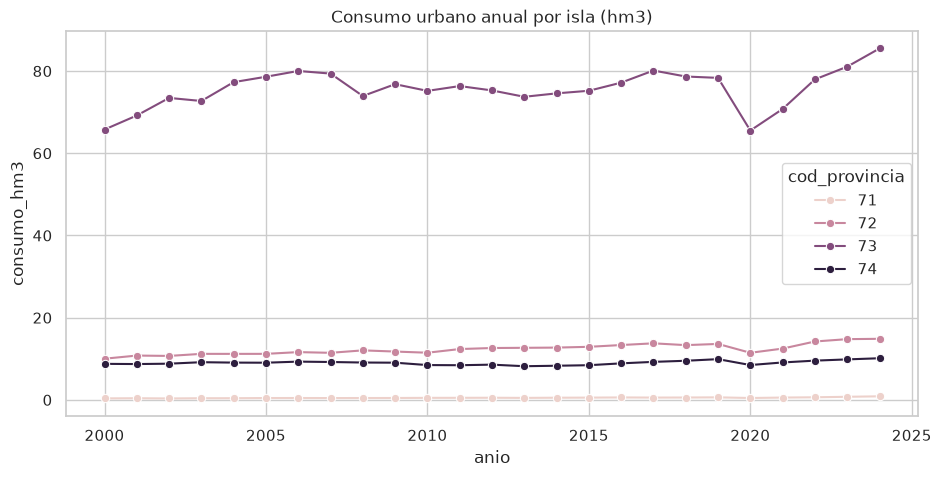

In [5]:
# Consumo por isla (provincias 071-074 = islas) y anio
mun = pl.read_csv(DATA / "municipio.csv", infer_schema_length=None).select(["cod_municipio", "cod_provincia", "nombre_municipio"])
df2 = df.join(mun, on="cod_municipio", how="left")

isla_anio = df2.group_by(["cod_provincia", "anio"]).agg(pl.col("consumo_hm3").sum().alias("consumo_hm3"))
sns.lineplot(data=isla_anio.to_pandas(), x="anio", y="consumo_hm3", hue="cod_provincia", marker="o")
plt.title("Consumo urbano anual por isla (hm3)")
plt.show()


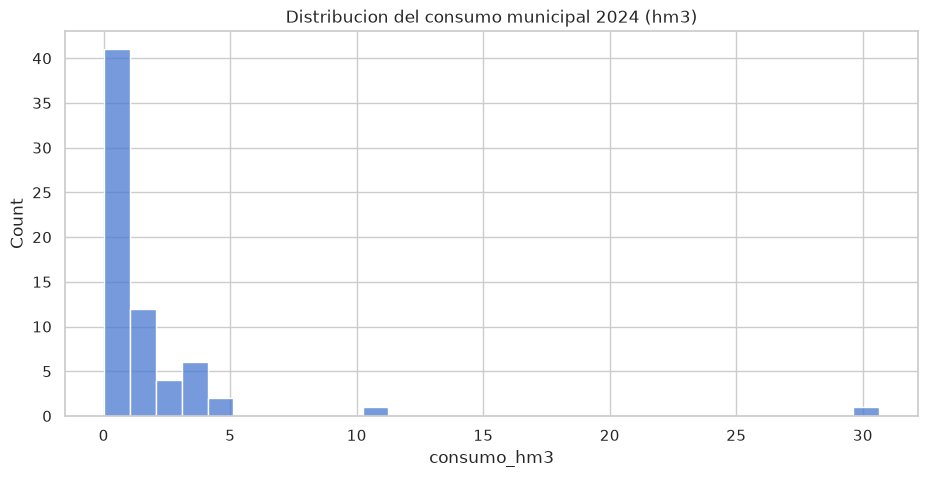

nombre_municipio,consumo_hm3
str,f64
"""Palma""",30.645
"""Calvià""",10.917
"""Alcúdia""",4.333
"""Santa Eulària des Riu""",4.182
"""Manacor""",4.076
"""Eivissa""",4.008
"""Sant Josep de sa Talaia""",3.878
"""Ciutadella de Menorca""",3.522
"""Santanyí""",3.335


In [6]:
# Distribucion del consumo municipal en el ultimo anio + top consumidores
ultimo = df2["anio"].max()
ult = df2.filter(pl.col("anio") == ultimo)
sns.histplot(ult["consumo_hm3"].to_pandas(), bins=30)
plt.title(f"Distribucion del consumo municipal {ultimo} (hm3)")
plt.show()

ult.sort("consumo_hm3", descending=True).head(10).select(["nombre_municipio", "consumo_hm3"])


correlacion total_suministrado vs consumo: 0.996


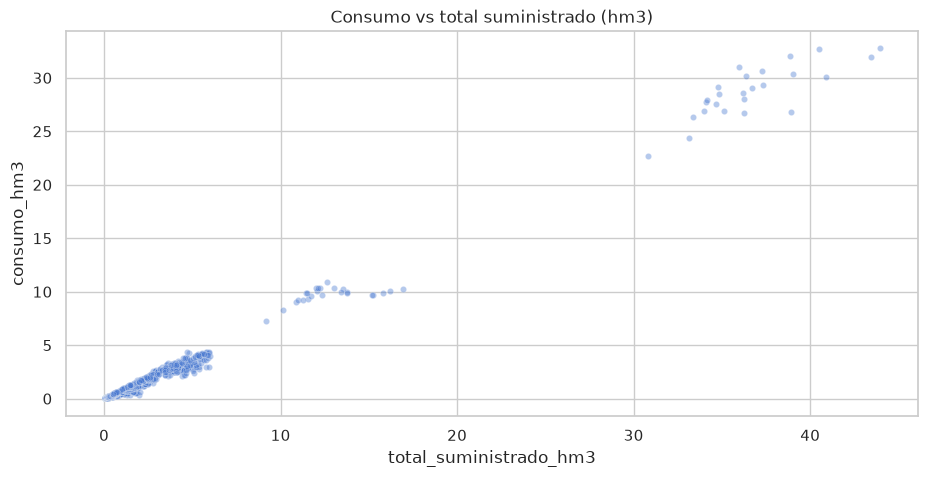

subterranea_hm3,desalinizada_hm3,indiferenciada_hm3,superficial_hm3,potabilizada_hm3
f64,f64,f64,f64,f64
1.360612,0.198906,0.196126,0.12227,0.131104


In [7]:
# Relacion consumo vs total suministrado (perdidas / usos no registrados)
corr = df.select(pl.corr("total_suministrado_hm3", "consumo_hm3")).item()
print(f"correlacion total_suministrado vs consumo: {corr:.3f}")
sns.scatterplot(data=df.to_pandas(), x="total_suministrado_hm3", y="consumo_hm3", alpha=0.4, s=20)
plt.title("Consumo vs total suministrado (hm3)")
plt.show()

# Origenes del agua suministrada (media anual por origen, toda la serie)
origenes = ["subterranea_hm3", "desalinizada_hm3", "indiferenciada_hm3", "superficial_hm3", "potabilizada_hm3"]
df2.select([pl.col(c).mean().alias(c) for c in origenes])


**Conclusiones EDA**

- Serie **completa**: 67 municipios x 25 anios (2000-2024), sin nulos en `consumo_hm3`.
- El consumo urbano de Baleares crece a lo largo de la serie (ver grafico por isla); Mallorca domina el total.
- `consumo_hm3` correlaciona fuertemente con `total_suministrado_hm3`; el consumo es una fraccion del suministrado (perdidas + usos no registrados).
- **Target del modelado**: `consumo_hm3` anual por municipio (municipio x anio).
